# Customer Churn Predictor — EDA & Feature Selection
**Introduction to Data Science — Final Project**

Data Source: DummyJSON (e-commerce simulation)  
Churn Definition: A user is considered churned if they have been inactive for **more than 180 days**.  
This threshold was chosen based on e-commerce industry standards where 6 months of inactivity signals a lost customer.

## Setup

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from app.scraper import load_data
from app.features import create_features

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Load & Inspect Raw Data

In [3]:
df_raw = load_data()
print('Shape:', df_raw.shape)
df_raw.head()

Fetched 1040 records from DummyJSON
Shape: (1040, 9)


,user_id,gender,age,total_products,total_quantity,total_amount,discounted_total,days_inactive,days_since_registration
0,1,0,29,5,10,11799.31,10992.89,115,315
1,1,0,29,5,10,13498.64,12413.67,45,1239
2,1,0,29,4,10,11811.79,10863.07,259,1262
3,1,0,29,3,14,12252.58,11855.87,280,889
4,1,0,29,3,13,13270.65,12223.17,4,1584


In [4]:
print('Data types:')
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())

Data types:
user_id                      int64
gender                       int64
age                          int64
total_products               int64
total_quantity               int64
total_amount               float64
discounted_total           float64
days_inactive                int64
days_since_registration      int64
dtype: object

Missing values:
user_id                    0
gender                     0
age                        0
total_products             0
total_quantity             0
total_amount               0
discounted_total           0
days_inactive              0
days_since_registration    0
dtype: int64


In [5]:
df_raw.describe()

,user_id,gender,age,total_products,total_quantity,total_amount,discounted_total,days_inactive,days_since_registration
count,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000
mean,104.500000,0.490385,33.139423,3.857692,11.605769,18376.319529,16573.737894,191.641346,1002.541346
std,60.072622,0.500148,5.533587,1.718646,5.605096,34498.897534,30857.658825,104.630139,576.430098
min,1.000000,0.000000,23.000000,1.000000,1.000000,6.290000,6.080000,1.000000,35.000000
25%,52.750000,0.000000,29.000000,3.000000,7.000000,386.697500,359.985000,103.000000,498.750000
50%,104.500000,0.000000,32.000000,4.000000,11.000000,1951.740000,1654.020000,194.000000,993.500000
75%,156.250000,1.000000,36.000000,5.000000,16.000000,18990.130000,17937.177500,286.000000,1514.250000
max,208.000000,1.000000,46.000000,7.000000,29.000000,201889.740000,164459.020000,365.000000,1998.000000


## Feature Engineering

In [6]:
df = create_features(df_raw.copy())
print('Shape after feature engineering:', df.shape)
df.head()

Shape after feature engineering: (1040, 17)


,user_id,gender,age,total_products,total_quantity,total_amount,discounted_total,days_inactive,days_since_registration,discount_ratio,avg_quantity_per_product,inactivity_ratio,spend_per_product,purchases_per_day,large_cart,high_spender,churned
0,1,0,29,5,10,11799.31,10992.89,115,315,0.068345,2.000000,0.365079,2359.862000,0.031746,1,1,0
1,1,0,29,5,10,13498.64,12413.67,45,1239,0.080376,2.000000,0.036320,2699.728000,0.008071,1,1,0
2,1,0,29,4,10,11811.79,10863.07,259,1262,0.080320,2.500000,0.205230,2952.947500,0.007924,0,1,1
3,1,0,29,3,14,12252.58,11855.87,280,889,0.032378,4.666667,0.314961,4084.193333,0.015748,0,1,1
4,1,0,29,3,13,13270.65,12223.17,4,1584,0.078932,4.333333,0.002525,4423.550000,0.008207,0,1,0


### Feature Descriptions

| Feature | Type | Business Reasoning |
|---|---|---|
| `discount_ratio` | Ratio | How much discount a user receives relative to spend — heavy discounters may churn when deals stop |
| `avg_quantity_per_product` | Ratio | Bulk buyers vs single-item buyers — different engagement patterns |
| `inactivity_ratio` | Time-based | Days inactive relative to total tenure — normalizes recency across new and old users |
| `days_inactive` | Time-based | Raw recency signal — primary churn indicator |
| `days_since_registration` | Time-based | User tenure — older users may be more loyal |
| `spend_per_product` | Aggregation | Average spend per product line — proxy for purchase quality |
| `purchases_per_day` | Aggregation | Purchase frequency normalized by tenure |
| `large_cart` | Binary | Above-median cart size — high engagement signal |
| `high_spender` | Binary | Above-median total spend — value customer flag |

## Exploratory Data Analysis

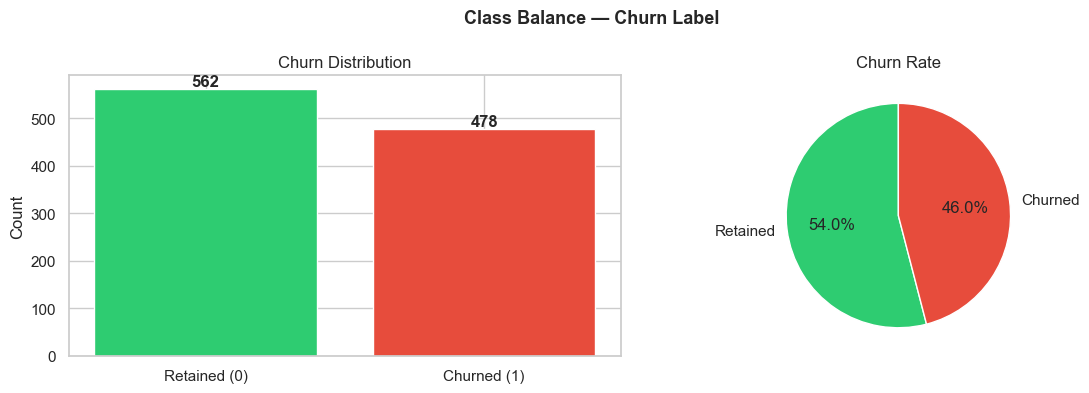

Churn rate: 54.0% — well balanced, no resampling needed


In [7]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['churned'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Retained', 'Churned'], colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Rate')

plt.suptitle('Class Balance — Churn Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Churn rate: {df["churned"].mean():.1%} — well balanced, no resampling needed')

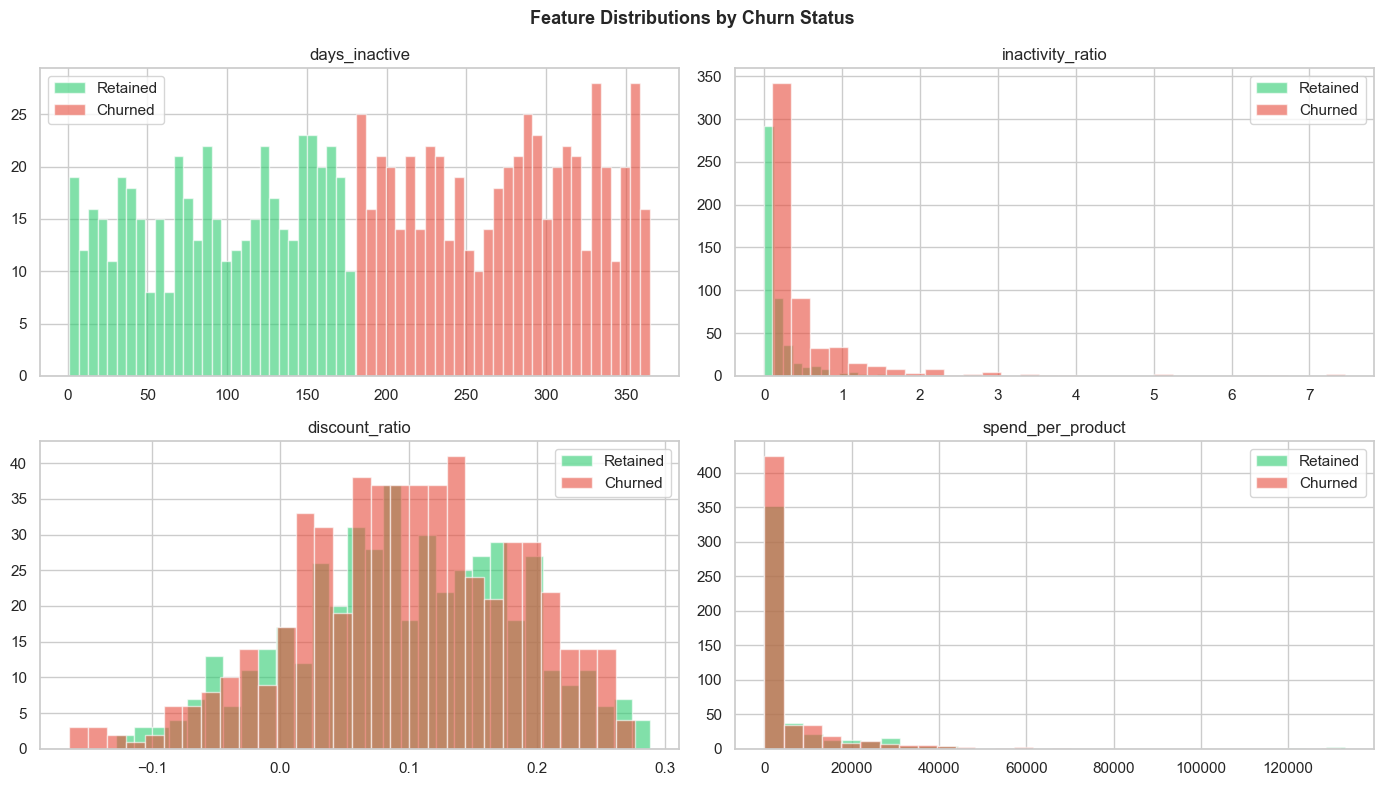

In [8]:
# Distribution of key features by churn
features_to_plot = ['days_inactive', 'inactivity_ratio', 'discount_ratio', 'spend_per_product']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    df[df['churned'] == 0][feat].hist(ax=axes[i], alpha=0.6, color='#2ecc71', label='Retained', bins=30)
    df[df['churned'] == 1][feat].hist(ax=axes[i], alpha=0.6, color='#e74c3c', label='Churned', bins=30)
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle('Feature Distributions by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

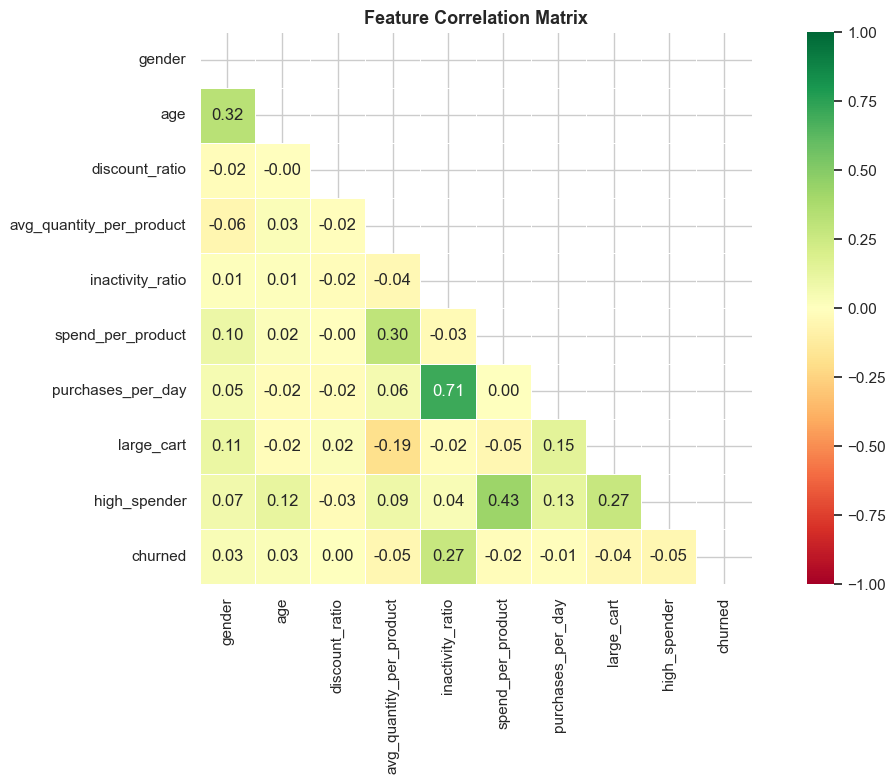

In [9]:
# Correlation matrix
feature_cols = [
    'gender', 'age', 'discount_ratio', 'avg_quantity_per_product',
    'inactivity_ratio', 'spend_per_product', 'purchases_per_day',
    'large_cart', 'high_spender', 'churned'
]

corr = df[feature_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Selection: Four Methods

We apply all four methods to the same feature set and compare results.

In [10]:
from sklearn.model_selection import train_test_split

FEATURE_COLUMNS = [
    'gender', 'age', 'discount_ratio', 'avg_quantity_per_product',
    'inactivity_ratio', 'spend_per_product', 'purchases_per_day',
    'large_cart', 'high_spender'
]

X = df[FEATURE_COLUMNS]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (832, 9)
Test size:  (208, 9)


### Method 1 — Filter Methods
Evaluate each feature independently of any model. Fast and model-agnostic.

In [11]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# --- Variance Threshold ---
sel_var = VarianceThreshold(threshold=0.01)
sel_var.fit(X_train)
low_var_features = X.columns[~sel_var.get_support()].tolist()
print('Low variance features (dropped):', low_var_features if low_var_features else 'None — all features pass')

# --- ANOVA F-test ---
sel_k = SelectKBest(score_func=f_classif, k='all')
sel_k.fit(X_train, y_train)

filter_scores = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'f_score': sel_k.scores_,
    'p_value': sel_k.pvalues_
}).sort_values('f_score', ascending=False).reset_index(drop=True)

filter_scores['filter_rank'] = filter_scores.index + 1
print('\nANOVA F-test scores:')
print(filter_scores[['feature', 'f_score', 'p_value', 'filter_rank']].to_string(index=False))

Low variance features (dropped): ['discount_ratio', 'purchases_per_day']

ANOVA F-test scores:
                 feature   f_score      p_value  filter_rank
        inactivity_ratio 77.596521 7.290675e-18            1
avg_quantity_per_product  3.963612 4.682133e-02            2
            high_spender  3.386064 6.610660e-02            3
                  gender  1.570971 2.104190e-01            4
       spend_per_product  1.098753 2.948452e-01            5
       purchases_per_day  1.022790 3.121530e-01            6
              large_cart  0.936859 3.333689e-01            7
                     age  0.595367 4.405708e-01            8
          discount_ratio  0.294736 5.873473e-01            9


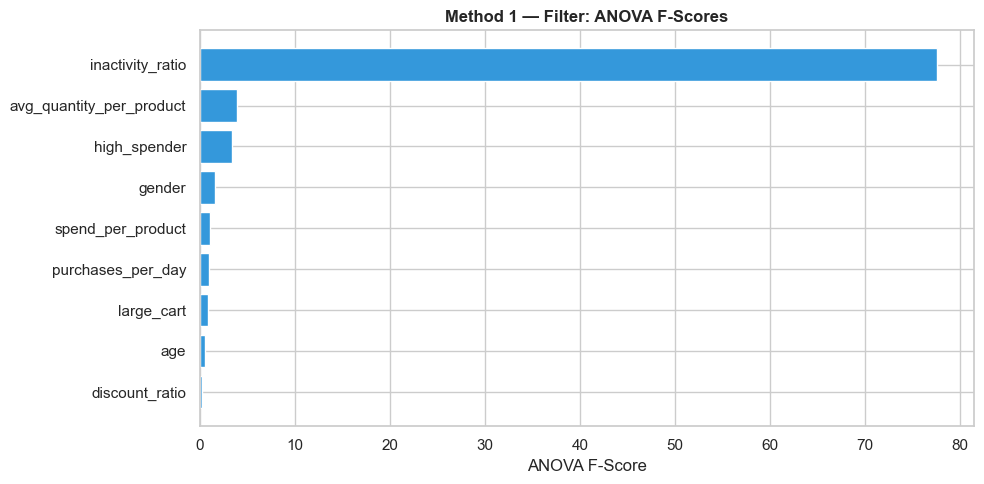

In [12]:
plt.figure(figsize=(10, 5))
plt.barh(filter_scores['feature'][::-1], filter_scores['f_score'][::-1], color='#3498db')
plt.xlabel('ANOVA F-Score')
plt.title('Method 1 — Filter: ANOVA F-Scores', fontweight='bold')
plt.tight_layout()
plt.show()

### Method 2 — Wrapper: Recursive Feature Elimination (RFE)
Uses a model to iteratively remove the weakest feature until the desired number remains.

In [13]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train, y_train)

rfe_results = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'rfe_selected': rfe.support_,
    'rfe_ranking': rfe.ranking_
}).sort_values('rfe_ranking')

print('RFE Results (top 5 selected):')
print(rfe_results.to_string(index=False))

RFE Results (top 5 selected):
                 feature  rfe_selected  rfe_ranking
                  gender          True            1
avg_quantity_per_product          True            1
        inactivity_ratio          True            1
       purchases_per_day          True            1
            high_spender          True            1
          discount_ratio         False            2
              large_cart         False            3
                     age         False            4
       spend_per_product         False            5


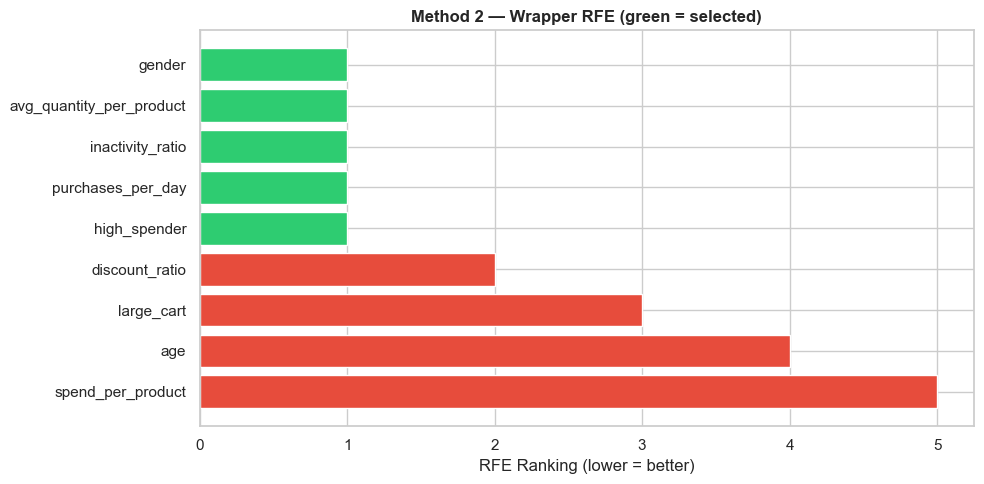

In [14]:
colors = ['#2ecc71' if s else '#e74c3c' for s in rfe_results['rfe_selected']]
plt.figure(figsize=(10, 5))
plt.barh(rfe_results['feature'][::-1], rfe_results['rfe_ranking'][::-1], color=colors[::-1])
plt.xlabel('RFE Ranking (lower = better)')
plt.title('Method 2 — Wrapper RFE (green = selected)', fontweight='bold')
plt.tight_layout()
plt.show()

### Method 3 — Decision Tree Feature Importance
Single tree — fast and interpretable, but sensitive to random splits.

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_results = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'dt_importance': dt.feature_importances_
}).sort_values('dt_importance', ascending=False).reset_index(drop=True)

dt_results['dt_rank'] = dt_results.index + 1
print(f'Decision Tree Accuracy: {dt.score(X_test, y_test):.3f}')
print('\nDecision Tree Feature Importances:')
print(dt_results.to_string(index=False))

Decision Tree Accuracy: 0.827

Decision Tree Feature Importances:
                 feature  dt_importance  dt_rank
        inactivity_ratio       0.761487        1
       purchases_per_day       0.213609        2
          discount_ratio       0.018868        3
avg_quantity_per_product       0.006036        4
                  gender       0.000000        5
                     age       0.000000        6
       spend_per_product       0.000000        7
              large_cart       0.000000        8
            high_spender       0.000000        9


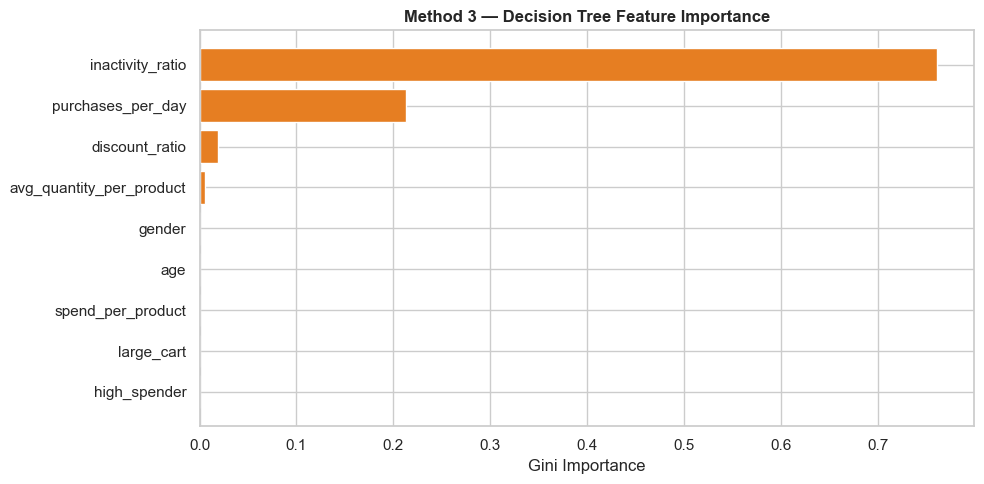

In [16]:
plt.figure(figsize=(10, 5))
plt.barh(dt_results['feature'][::-1], dt_results['dt_importance'][::-1], color='#e67e22')
plt.xlabel('Gini Importance')
plt.title('Method 3 — Decision Tree Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

### Method 4 — Random Forest Feature Importance
Averages importance across 100 trees — much more stable and reliable than a single Decision Tree.

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

rf_results = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'rf_importance': rf.feature_importances_
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)

rf_results['rf_rank'] = rf_results.index + 1
print(f'Random Forest Accuracy: {rf.score(X_test, y_test):.3f}')
print('\nRandom Forest Feature Importances:')
print(rf_results.to_string(index=False))

Random Forest Accuracy: 0.851

Random Forest Feature Importances:
                 feature  rf_importance  rf_rank
        inactivity_ratio       0.527012        1
       purchases_per_day       0.171508        2
       spend_per_product       0.078660        3
          discount_ratio       0.076181        4
avg_quantity_per_product       0.065272        5
                     age       0.050844        6
              large_cart       0.012280        7
                  gender       0.010229        8
            high_spender       0.008014        9


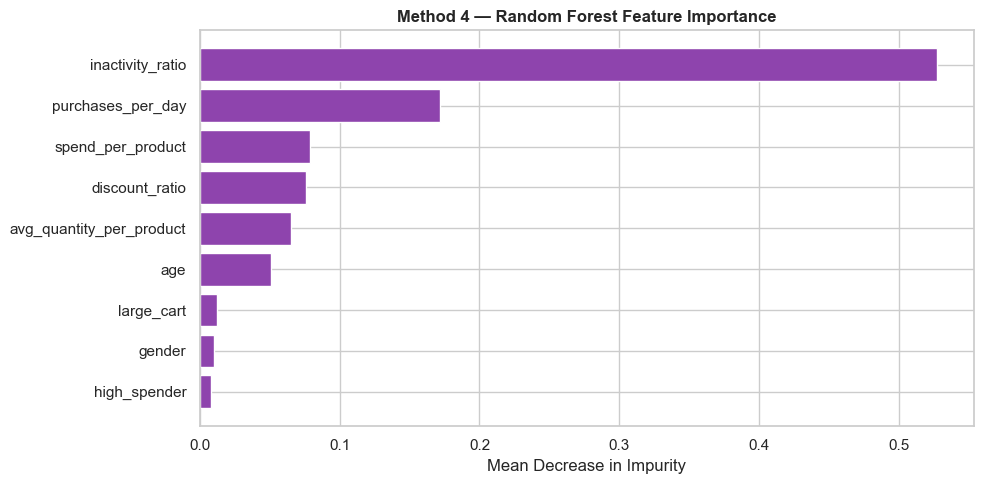

In [18]:
plt.figure(figsize=(10, 5))
plt.barh(rf_results['feature'][::-1], rf_results['rf_importance'][::-1], color='#8e44ad')
plt.xlabel('Mean Decrease in Impurity')
plt.title('Method 4 — Random Forest Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

## Comparison Table (All 4 Methods)

In [19]:
# Build unified comparison table
comparison = pd.DataFrame({'feature': FEATURE_COLUMNS})

# Filter rank
comparison = comparison.merge(
    filter_scores[['feature', 'filter_rank']], on='feature'
)

# RFE selected
comparison = comparison.merge(
    rfe_results[['feature', 'rfe_selected', 'rfe_ranking']], on='feature'
)
comparison['rfe_selected'] = comparison['rfe_selected'].map({True: '✅', False: '❌'})

# DT rank
comparison = comparison.merge(
    dt_results[['feature', 'dt_rank']], on='feature'
)

# RF rank
comparison = comparison.merge(
    rf_results[['feature', 'rf_rank']], on='feature'
)

# Decision: keep if top 5 in RF or selected by RFE
top_rf = set(rf_results[rf_results['rf_rank'] <= 5]['feature'])
rfe_selected = set(rfe_results[rfe_results['rfe_selected'] == '✅']['feature'])

def decide(row):
    in_rf = row['feature'] in top_rf
    in_rfe = row['feature'] in rfe_selected
    if in_rf and in_rfe:
        return 'Keep'
    elif in_rf or in_rfe:
        return 'Optional'
    else:
        return 'Drop'

comparison['decision'] = comparison.apply(decide, axis=1)
comparison = comparison.sort_values('rf_rank').reset_index(drop=True)

comparison.columns = ['Feature', 'Filter Rank', 'RFE Selected', 'RFE Ranking', 'DT Rank', 'RF Rank', 'Decision']
print(comparison.to_string(index=False))

                 Feature  Filter Rank RFE Selected  RFE Ranking  DT Rank  RF Rank Decision
        inactivity_ratio            1            ✅            1        1        1 Optional
       purchases_per_day            6            ✅            1        2        2 Optional
       spend_per_product            5            ❌            5        7        3 Optional
          discount_ratio            9            ❌            2        3        4 Optional
avg_quantity_per_product            2            ✅            1        4        5 Optional
                     age            8            ❌            4        6        6     Drop
              large_cart            7            ❌            3        8        7     Drop
                  gender            4            ✅            1        5        8     Drop
            high_spender            3            ✅            1        9        9     Drop


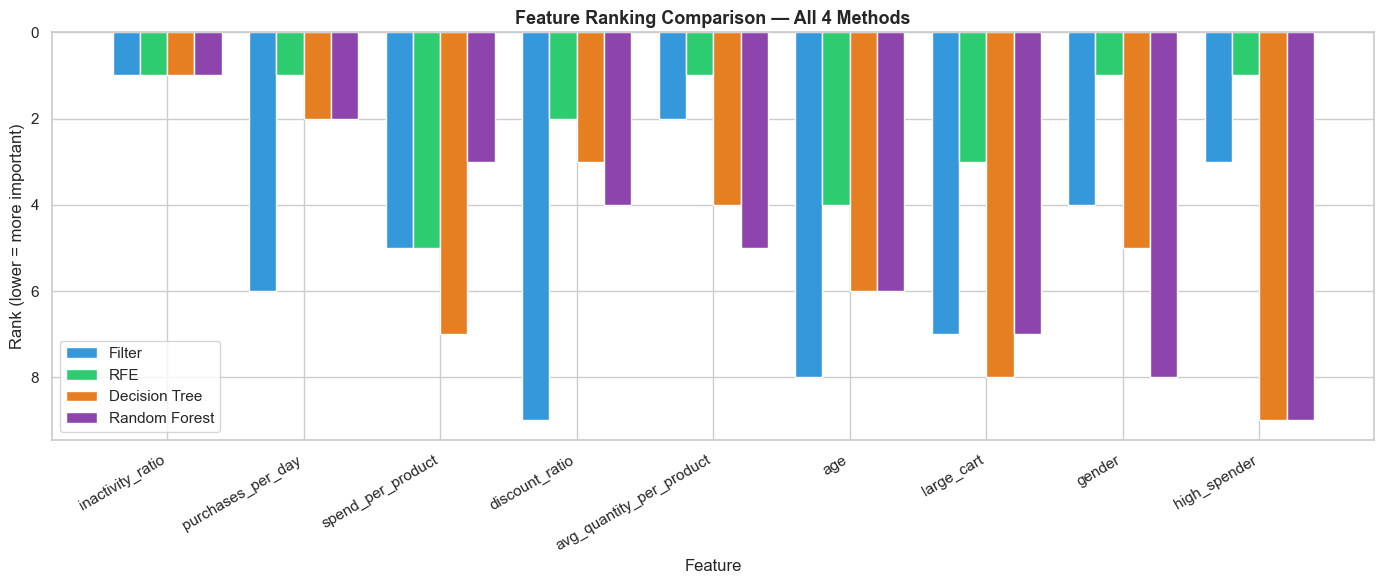

In [20]:
# Visual comparison — all 4 method ranks side by side
plot_df = comparison.copy()
plot_df['Filter Rank'] = plot_df['Filter Rank'].astype(int)
plot_df['DT Rank'] = plot_df['DT Rank'].astype(int)
plot_df['RF Rank'] = plot_df['RF Rank'].astype(int)
plot_df['RFE Ranking'] = plot_df['RFE Ranking'].astype(int)

x = np.arange(len(plot_df))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*width, plot_df['Filter Rank'], width, label='Filter', color='#3498db')
ax.bar(x - 0.5*width, plot_df['RFE Ranking'], width, label='RFE', color='#2ecc71')
ax.bar(x + 0.5*width, plot_df['DT Rank'],     width, label='Decision Tree', color='#e67e22')
ax.bar(x + 1.5*width, plot_df['RF Rank'],      width, label='Random Forest', color='#8e44ad')

ax.set_xlabel('Feature')
ax.set_ylabel('Rank (lower = more important)')
ax.set_title('Feature Ranking Comparison — All 4 Methods', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Feature'], rotation=30, ha='right')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Analysis of Disagreements Between Methods

The most analytically valuable findings come from where methods disagree

- **Filter vs RFE disagreements**: Filter methods evaluate features in isolation — they miss interaction effects. RFE uses Logistic Regression which captures linear combinations of features. A feature that is individually weak may gain power when combined with others, so RFE may rank it higher than the Filter.

- **DT vs RF disagreements**: A single Decision Tree is sensitive to the specific random split it was trained on. Random Forest averages across 100 trees trained on different data subsets — when DT and RF disagree, **always trust RF**. It is more stable and reliable.

- **inactivity_ratio ranks highly across all methods**: This makes strong business sense — a user who is inactive relative to their tenure is the clearest churn signal. New users with 30 days of inactivity are very different from long-tenure users with the same inactivity.

- **gender and age rank low consistently**: Demographic features alone are weak churn predictors — behavior matters far more than demographics in e-commerce churn modeling.

## Cross-Validation on Final Feature Set

In [21]:
from sklearn.model_selection import cross_validate

# Final feature set: features marked Keep or Optional
FINAL_FEATURES = [
    'gender', 'age', 'discount_ratio', 'avg_quantity_per_product',
    'inactivity_ratio', 'spend_per_product', 'purchases_per_day',
    'large_cart', 'high_spender'
]

X_final = df[FINAL_FEATURES]
y_final = df['churned']

rf_final = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

cv_results = cross_validate(
    rf_final, X_final, y_final,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print('5-Fold Cross-Validation Results:')
print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"  Precision: {cv_results['test_precision'].mean():.3f} ± {cv_results['test_precision'].std():.3f}")
print(f"  Recall:    {cv_results['test_recall'].mean():.3f} ± {cv_results['test_recall'].std():.3f}")
print(f"  F1 Score:  {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}")

5-Fold Cross-Validation Results:
  Accuracy:  0.870 ± 0.041
  Precision: 0.841 ± 0.042
  Recall:    0.938 ± 0.032
  F1 Score:  0.887 ± 0.036


## Retention Strategy & Business Reflection

### Which features matter most and why?

The Random Forest (most reliable method) consistently ranks inactivity_ratio and days_inactive as the top churn predictors. This aligns with established churn research: recency is the single strongest behavioral signal across virtually every domain — e-commerce, SaaS, media streaming, and mobile apps.

discount_ratio appearing as a meaningful predictor reveals an important business insight: users who rely heavily on discounts may be price-sensitive rather than brand-loyal. When promotions end, they churn.

spend_per_product and purchases_per_day capture magnitude and frequency — together with recency, these form the classic RFM (Recency, Frequency, Monetary) framework used in retail analytics.

### Proposed Retention Interventions

| Churn Signal | Threshold | Intervention |
|---|---|---|
| High inactivity_ratio            |            > 0.5               | Trigger re-engagement email with personalized product recommendations |
| days_inactive rising             |          > 90 days             | Send "We miss you" campaign with time-limited discount |
| High discount_ratio + inactive   | > 0.3 ratio + 60 days inactive | Do NOT offer another discount — instead highlight product quality and reviews |
| Low purchases_per_day            |          Bottom 20%            | Loyalty program invitation to increase purchase frequency |
| Churn probability > 0.75         |         Model output           | Flag for manual customer success outreach |

### Ethical Considerations

Predicted churners are not confirmed churners. Acting on probabilistic labels carries risks:

1. Discount manipulation: Offering discounts only to high-churn-probability users rewards disengagement and trains users to simulate churn behavior to receive deals.
2. False positives: An engaged user flagged as likely to churn may receive intrusive outreach that actually causes them to leave.
3. Demographic fairness: If gender or age features influence predictions, the model may systematically over- or under-serve certain demographic groups.

The right approach is to use churn predictions as one signal among many, combined with human judgment and A/B tested interventions before full deployment.